In [1]:
# Optional: uncomment if your notebook does not have these packages
# %pip install numpy pandas scipy matplotlib openpyxl

import math
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

In [3]:
# Update this path if needed
DATA_PATH = Path("Data_File.xls")  # 已修改为当前目录中的数据文件

def load_project_data(path: str | Path) -> dict[str, np.ndarray]:
    """
    Read the uploaded file.
    This file is not a true binary Excel workbook; it is a tab-separated text file.
    Each line has:
        series_name \t x1 \t x2 \t ... \t x200
    """
    path = Path(path)
    data = {}

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            parts = [p.strip() for p in line.split("\t") if p.strip() != ""]
            series_name = parts[0]
            values = np.array([float(x) for x in parts[1:]], dtype=float)
            data[series_name] = values

    return data

data = load_project_data(DATA_PATH)

list(data.keys())

['Interarrival Times',
 'Service Times for Initial Phase',
 'Service Times for Placing Keyboard and Mouse',
 'Service Times for Assembling the Case (Aluminum Plates)']

In [4]:
summary_rows = []

for name, x in data.items():
    summary_rows.append({
        "series": name,
        "n": len(x),
        "mean": np.mean(x),
        "sd_sample": np.std(x, ddof=1),
        "min": np.min(x),
        "max": np.max(x),
        "median": np.median(x)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,series,n,mean,sd_sample,min,max,median
0,Interarrival Times,200,6.509928,5.671824,0.130480,28.91880,4.833945
1,Service Times for Initial Phase,200,2.701968,0.879895,0.990284,5.89407,2.569685
2,Service Times for Placing Keyboard and Mouse,200,9.944270,2.249778,5.853910,13.73790,10.071450
3,Service Times for Assembling the Case (Aluminu...,200,3.857041,1.097934,0.013265,6.56471,3.889190


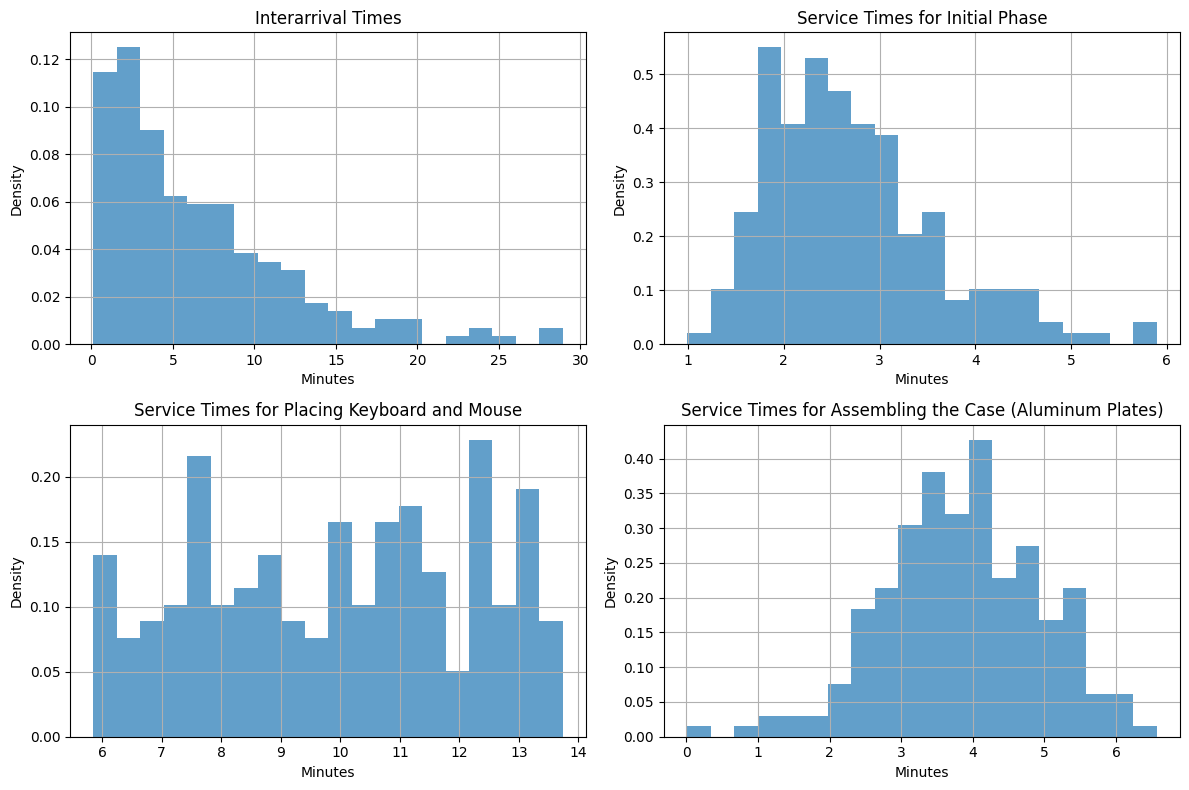

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, x) in zip(axes, data.items()):
    ax.hist(x, bins=20, density=True, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel("Minutes")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

In [6]:
def fit_distribution(x: np.ndarray, dist_name: str) -> dict:
    """
    Fit one candidate distribution and run a KS goodness-of-fit test.
    For positive-support distributions we fix loc=0.
    """
    x = np.asarray(x, dtype=float)

    if dist_name == "expon":
        dist = st.expon
        params = dist.fit(x, floc=0)
        ks_name = "expon"

    elif dist_name == "lognorm":
        dist = st.lognorm
        params = dist.fit(x, floc=0)
        ks_name = "lognorm"

    elif dist_name == "gamma":
        dist = st.gamma
        params = dist.fit(x, floc=0)
        ks_name = "gamma"

    elif dist_name == "weibull_min":
        dist = st.weibull_min
        params = dist.fit(x, floc=0)
        ks_name = "weibull_min"

    elif dist_name == "norm":
        dist = st.norm
        params = dist.fit(x)
        ks_name = "norm"

    elif dist_name == "uniform":
        dist = st.uniform
        params = dist.fit(x)
        ks_name = "uniform"

    else:
        raise ValueError(f"Unsupported distribution: {dist_name}")

    ks = st.kstest(x, ks_name, args=params)

    return {
        "distribution": dist_name,
        "params": params,
        "ks_stat": ks.statistic,
        "ks_pvalue": ks.pvalue
    }


def compare_candidates(x: np.ndarray, candidates: list[str]) -> pd.DataFrame:
    rows = []
    for name in candidates:
        result = fit_distribution(x, name)
        rows.append({
            "distribution": result["distribution"],
            "params": result["params"],
            "ks_stat": result["ks_stat"],
            "ks_pvalue": result["ks_pvalue"]
        })
    out = pd.DataFrame(rows).sort_values(["ks_stat", "ks_pvalue"], ascending=[True, False])
    return out.reset_index(drop=True)

In [7]:
arrival_candidates = ["expon", "lognorm", "gamma", "weibull_min", "norm"]
positive_candidates = ["lognorm", "gamma", "weibull_min", "norm", "uniform"]

fit_arrival = compare_candidates(data["Interarrival Times"], arrival_candidates)
fit_initial = compare_candidates(data["Service Times for Initial Phase"], positive_candidates)
fit_keymouse = compare_candidates(data["Service Times for Placing Keyboard and Mouse"], positive_candidates)
fit_case = compare_candidates(data["Service Times for Assembling the Case (Aluminum Plates)"], positive_candidates)

print("Interarrival candidates")
display(fit_arrival)

print("Initial Phase candidates")
display(fit_initial)

print("Placing Keyboard and Mouse candidates")
display(fit_keymouse)

print("Assembling the Case candidates")
display(fit_case)

Interarrival candidates


,distribution,params,ks_stat,ks_pvalue
0,weibull_min,"(1.1525840059893047, 0, 6.847169573776267)",0.034305,0.966274
1,gamma,"(1.2565882899205254, 0, 5.180636913632013)",0.039177,0.906669
2,expon,"(0.0, 6.5099276800000005)",0.070525,0.260391
3,lognorm,"(1.0878108950933014, 0, 4.15924737956936)",0.077505,0.171609
4,norm,"(6.5099276800000005, 5.657626344775283)",0.129748,0.002143


Initial Phase candidates


,distribution,params,ks_stat,ks_pvalue
0,lognorm,"(0.31297747061100606, 0, 2.571475050634617)",0.035423,9.556652e-01
1,gamma,"(10.264684267565189, 0, 0.263229569421614)",0.055428,5.517351e-01
2,weibull_min,"(3.1755542959853917, 0, 3.0125891536510676)",0.091844,6.425002e-02
3,norm,"(2.70196842, 0.8776927580315241)",0.097392,4.201195e-02
4,uniform,"(0.990284, 4.903786)",0.339821,4.102655e-21


Placing Keyboard and Mouse candidates


,distribution,params,ks_stat,ks_pvalue
0,uniform,"(5.85391, 7.88399)",0.061653,0.415949
1,norm,"(9.9442696, 2.2441461792685966)",0.078458,0.161600
2,weibull_min,"(5.156622814166055, 0, 10.83837032716943)",0.082055,0.127950
3,gamma,"(18.51339026975728, 0, 0.5371393059349348)",0.095909,0.047180
4,lognorm,"(0.23785124489163423, 0, 9.676941811482498)",0.107054,0.018887


Assembling the Case candidates


,distribution,params,ks_stat,ks_pvalue
0,norm,"(3.8570414465, 1.095185575685321)",0.024018,9.996886e-01
1,weibull_min,"(3.822218214783548, 0, 4.234283559645673)",0.041366,8.691858e-01
2,gamma,"(7.536947128774841, 0, 0.5117511613919171)",0.099394,3.582118e-02
3,lognorm,"(0.5080757522987929, 0, 3.6041866793858612)",0.166054,2.742253e-05
4,uniform,"(0.0132653, 6.5514447)",0.292039,1.322383e-15


In [8]:
# 1) Interarrival: assignment says exponential structure is known
interarrival_mean = np.mean(data["Interarrival Times"])
lambda_hat = 1.0 / interarrival_mean

# 2) Initial Phase: choose lognormal
lognorm_fit = fit_distribution(data["Service Times for Initial Phase"], "lognorm")
shape_lognorm, loc_lognorm, scale_lognorm = lognorm_fit["params"]
mu_log = math.log(scale_lognorm)   # SciPy lognorm uses scale = exp(mu)
sigma_log = shape_lognorm

# Convert log-scale params to raw-scale mean and sd (useful for Simul8 if needed)
raw_mean_lognorm = math.exp(mu_log + 0.5 * sigma_log**2)
raw_sd_lognorm = math.sqrt((math.exp(sigma_log**2) - 1) * math.exp(2 * mu_log + sigma_log**2))

# 3) Placing Keyboard and Mouse: choose uniform
uniform_keymouse = fit_distribution(data["Service Times for Placing Keyboard and Mouse"], "uniform")
loc_u_km, width_u_km = uniform_keymouse["params"]
a_km = loc_u_km
b_km = loc_u_km + width_u_km

# 4) Assemble Case: choose normal
normal_case = fit_distribution(data["Service Times for Assembling the Case (Aluminum Plates)"], "norm")
mu_case, sd_case = normal_case["params"]

chosen_inputs = {
    "Interarrival": {
        "family": "Exponential",
        "mean": interarrival_mean,
        "lambda_per_minute": lambda_hat
    },
    "InitialPhase": {
        "family": "Lognormal",
        "mu_log": mu_log,
        "sigma_log": sigma_log,
        "raw_mean": raw_mean_lognorm,
        "raw_sd": raw_sd_lognorm
    },
    "PlaceKeyboardMouse": {
        "family": "Uniform",
        "a": a_km,
        "b": b_km
    },
    "AssembleCase": {
        "family": "Normal",
        "mean": mu_case,
        "sd": sd_case
    }
}

chosen_inputs

{'Interarrival': {'family': 'Exponential',
  'mean': 6.5099276800000005,
  'lambda_per_minute': 0.15361153750943052},
 'InitialPhase': {'family': 'Lognormal',
  'mu_log': 0.9444796839242915,
  'sigma_log': 0.31297747061100606,
  'raw_mean': 2.7005545275031952,
  'raw_sd': 0.8663395736228755},
 'PlaceKeyboardMouse': {'family': 'Uniform', 'a': 5.85391, 'b': 13.7379},
 'AssembleCase': {'family': 'Normal',
  'mean': 3.8570414465,
  'sd': 1.095185575685321}}

In [10]:
report_input_table = pd.DataFrame([
    {
        "process": "Order interarrival",
        "chosen_family": "Exponential",
        "parameter_1": f"mean = {chosen_inputs['Interarrival']['mean']:.4f}",
        "parameter_2": f"lambda = {chosen_inputs['Interarrival']['lambda_per_minute']:.4f} per minute"
    },
    {
        "process": "Initial Phase",
        "chosen_family": "Lognormal",
        "parameter_1": f"mu_log = {chosen_inputs['InitialPhase']['mu_log']:.4f}",
        "parameter_2": f"sigma_log = {chosen_inputs['InitialPhase']['sigma_log']:.4f}"
    },
    {
        "process": "Placing Keyboard and Mouse",
        "chosen_family": "Uniform",
        "parameter_1": f"a = {chosen_inputs['PlaceKeyboardMouse']['a']:.4f}",
        "parameter_2": f"b = {chosen_inputs['PlaceKeyboardMouse']['b']:.4f}"
    },
    {
        "process": "Assembling the Case",
        "chosen_family": "Normal",
        "parameter_1": f"mean = {chosen_inputs['AssembleCase']['mean']:.4f}",
        "parameter_2": f"sd = {chosen_inputs['AssembleCase']['sd']:.4f}"
    }
])

report_input_table

,process,chosen_family,parameter_1,parameter_2
0,Order interarrival,Exponential,mean = 6.5099,lambda = 0.1536 per minute
1,Initial Phase,Lognormal,mu_log = 0.9445,sigma_log = 0.3130
2,Placing Keyboard and Mouse,Uniform,a = 5.8539,b = 13.7379
3,Assembling the Case,Normal,mean = 3.8570,sd = 1.0952


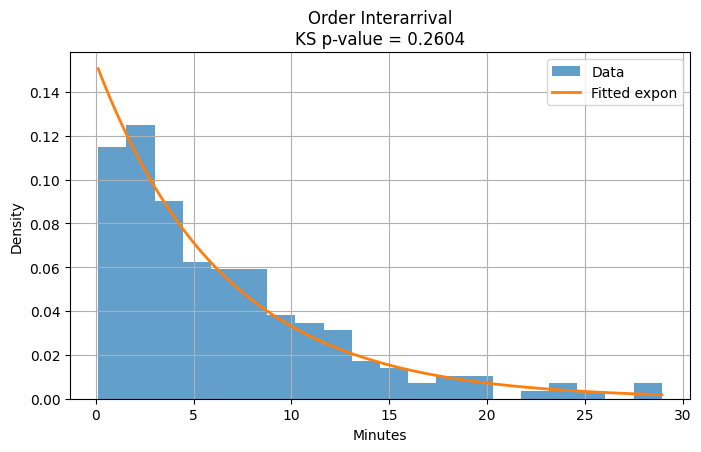

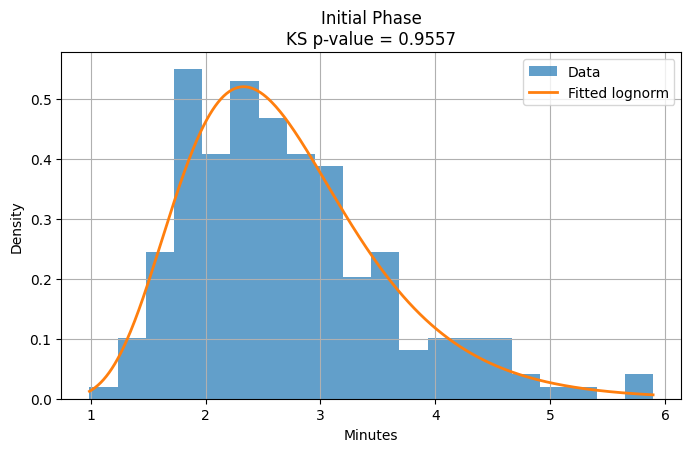

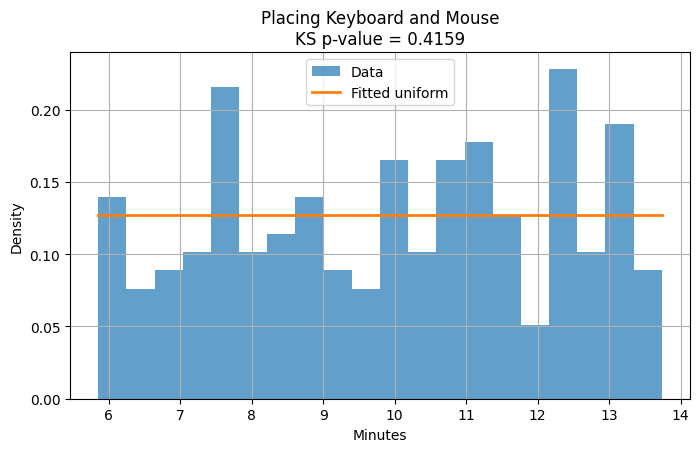

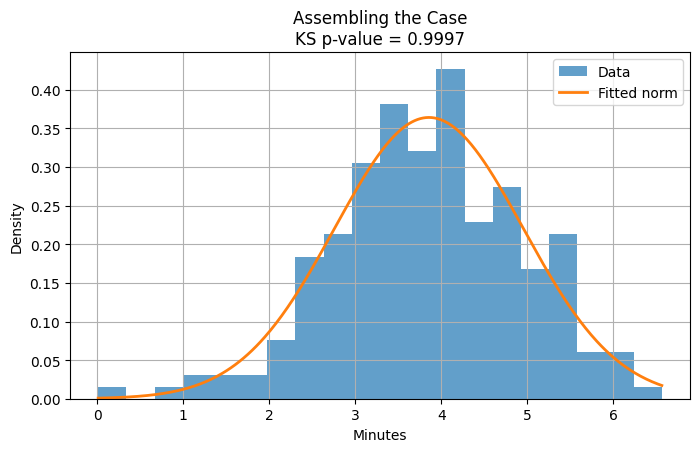

In [11]:
def plot_hist_with_fit(x: np.ndarray, dist_name: str, title: str, bins: int = 20):
    fit = fit_distribution(x, dist_name)
    params = fit["params"]

    xs = np.linspace(np.min(x), np.max(x), 400)

    if dist_name == "expon":
        pdf = st.expon.pdf(xs, *params)
    elif dist_name == "lognorm":
        pdf = st.lognorm.pdf(xs, *params)
    elif dist_name == "gamma":
        pdf = st.gamma.pdf(xs, *params)
    elif dist_name == "weibull_min":
        pdf = st.weibull_min.pdf(xs, *params)
    elif dist_name == "norm":
        pdf = st.norm.pdf(xs, *params)
    elif dist_name == "uniform":
        pdf = st.uniform.pdf(xs, *params)
    else:
        raise ValueError("Unsupported distribution")

    plt.figure(figsize=(8, 4.5))
    plt.hist(x, bins=bins, density=True, alpha=0.7, label="Data")
    plt.plot(xs, pdf, linewidth=2, label=f"Fitted {dist_name}")
    plt.title(f"{title}\nKS p-value = {fit['ks_pvalue']:.4f}")
    plt.xlabel("Minutes")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


plot_hist_with_fit(data["Interarrival Times"], "expon", "Order Interarrival")
plot_hist_with_fit(data["Service Times for Initial Phase"], "lognorm", "Initial Phase")
plot_hist_with_fit(data["Service Times for Placing Keyboard and Mouse"], "uniform", "Placing Keyboard and Mouse")
plot_hist_with_fit(data["Service Times for Assembling the Case (Aluminum Plates)"], "norm", "Assembling the Case")

In [12]:
MODEL_SPEC = {
    "known_process_times": {
        "PowerAssembly": {"family": "Uniform", "a": 2.0, "b": 6.0},
        "MainPartAssembly": {"family": "Triangular", "low": 5.0, "mode": 8.0, "high": 15.0},
        "CutPlate": {"family": "Fixed", "value": 8.0},
        "ShapeScreen": {"family": "Uniform", "a": 3.0, "b": 5.0},
        "PlaceScreen": {"family": "Uniform", "a": 4.0, "b": 10.0},
        "KeyBodyCut": {"family": "Uniform", "a": 5.0, "b": 8.0},
        "HDPeripherals": {"family": "Expression", "expr": "1 + 3*Beta(3,2)"},
        "PlaceMB": {"family": "Uniform", "a": 4.0, "b": 8.0},
        "QA": {"family": "Triangular", "low": 8.0, "mode": 14.0, "high": 16.0},
        "Boxing": {"family": "Uniform", "a": 4.0, "b": 8.0}
    },
    "estimated_process_times": chosen_inputs,
    "order_size": {
        "family": "1 + Binomial(5, 0.6)"
    },
    "resources": {
        "Type1Workers": 7,
        "Type2Workers": 3,
        "Type3Workers": 3,
        "Type4Workers": 2,
        "Type5Workers": 2,
        "RollCutMachines": 2,
        "SpecialMachines": 3,
        "Workbenches": 2
    },
    "inventory": {
        "AluminumBlocks": {
            "initial": 50,
            "s": 10,
            "Q": 50,
            "lead_time_minutes": 15 * 60
        },
        "HardDisks": {
            "initial": 70,
            "s": 10,
            "Q": 70,
            "lead_time_minutes": 15 * 60
        }
    },
    "queue_rules": {
        "WIP_limit_total_laptops": 100,
        "PowerAssemblyQueueCapacity": 3,
        "MainPartAssemblyQueueCapacity": 2,
        "PowerToStorageMoveTime": 2,
        "StorageToMainQueueMoveTime": 3
    },
    "rework": {
        "KeyCut": {
            "fail_after_1st_prob": 0.2,
            "fail_after_2nd_prob": 0.1,
            "max_attempts": 3
        }
    }
}

MODEL_SPEC

{'known_process_times': {'PowerAssembly': {'family': 'Uniform',
   'a': 2.0,
   'b': 6.0},
  'MainPartAssembly': {'family': 'Triangular',
   'low': 5.0,
   'mode': 8.0,
   'high': 15.0},
  'CutPlate': {'family': 'Fixed', 'value': 8.0},
  'ShapeScreen': {'family': 'Uniform', 'a': 3.0, 'b': 5.0},
  'PlaceScreen': {'family': 'Uniform', 'a': 4.0, 'b': 10.0},
  'KeyBodyCut': {'family': 'Uniform', 'a': 5.0, 'b': 8.0},
  'HDPeripherals': {'family': 'Expression', 'expr': '1 + 3*Beta(3,2)'},
  'PlaceMB': {'family': 'Uniform', 'a': 4.0, 'b': 8.0},
  'QA': {'family': 'Triangular', 'low': 8.0, 'mode': 14.0, 'high': 16.0},
  'Boxing': {'family': 'Uniform', 'a': 4.0, 'b': 8.0}},
 'estimated_process_times': {'Interarrival': {'family': 'Exponential',
   'mean': 6.5099276800000005,
   'lambda_per_minute': 0.15361153750943052},
  'InitialPhase': {'family': 'Lognormal',
   'mu_log': 0.9444796839242915,
   'sigma_log': 0.31297747061100606,
   'raw_mean': 2.7005545275031952,
   'raw_sd': 0.8663395736228755

In [13]:
math_model_notes = {
    "state_variables": [
        "W(t): number of laptops currently in system",
        "I_A(t): aluminum inventory level",
        "I_H(t): hard disk inventory level",
        "Queue lengths at each stage",
        "Resource occupancies for worker/machine pools"
    ],
    "arrival_process": [
        "Interarrival times T_n ~ Exponential(lambda_hat)",
        "Order size D_n = 1 + Binomial(5, 0.6)"
    ],
    "acceptance_rule": [
        "Accept order only if current WIP + order size <= 100"
    ],
    "assembly_start_rule": [
        "Motherboard ready",
        "Upper body ready",
        "Lower body ready",
        "Workbench available"
    ],
    "main_output_measure": [
        "Average laptop cycle time",
        "CI half-width target <= 1"
    ]
}

math_model_notes

{'state_variables': ['W(t): number of laptops currently in system',
  'I_A(t): aluminum inventory level',
  'I_H(t): hard disk inventory level',
  'Queue lengths at each stage',
  'Resource occupancies for worker/machine pools'],
 'arrival_process': ['Interarrival times T_n ~ Exponential(lambda_hat)',
  'Order size D_n = 1 + Binomial(5, 0.6)'],
 'acceptance_rule': ['Accept order only if current WIP + order size <= 100'],
 'assembly_start_rule': ['Motherboard ready',
  'Upper body ready',
  'Lower body ready',
  'Workbench available'],
 'main_output_measure': ['Average laptop cycle time',
  'CI half-width target <= 1']}

In [14]:
SIMUL8_BUILD_MANIFEST = {
    "labels": [
        "lblOrderID",
        "lblOrderSize",
        "lblArrivalTime",
        "lblLaptopID",
        "lblPartType",
        "lblKeyCutAttempt",
        "lblCycleTime",
        "lblRoute",
        "lblTempRand"
    ],
    "global_variables": [
        "glbNextOrderID",
        "glbNextLaptopID",
        "glbALInventory",
        "glbHDInventory",
        "glbInSystem",
        "glbRejectedOrders",
        "glbRejectedLaptops",
        "glbALOutstanding",
        "glbHDOutstanding",
        "glbBusyBench",
        "glbTotalCycleTime",
        "glbCompletedLaptops",
        "glbCounted",
        "glbTotalCT",
        "glbAverageCT",
        "i"
    ],
    "spreadsheets": [
        "OrderStatus",
        "LaptopStatus",
        "AssemblyStatus",
        "WarmUpData",
        "DataCalc"
    ],
    "main_objects": [
        "SP_Order",
        "A_AcceptOrder",
        "Q_SplitLaptop",
        "A_SplitLaptop",
        "Q_Initial",
        "A_Initial",
        "Q_Power",
        "A_Power",
        "Q_Main",
        "A_Main",
        "A_ToStorage",
        "Q_MBStorage",
        "A_FromStorage",
        "Q_CutDispatch",
        "A_CutPlate",
        "Q_ShapeScreen",
        "A_ShapeScreen",
        "Q_PlaceScreen",
        "A_PlaceScreen",
        "Q_KeyCut",
        "A_KeyCut",
        "Q_KeyMouse",
        "A_KeyMouse",
        "Q_AssemblyHold",
        "Q_HDAsm",
        "A_HDAsm",
        "Q_CaseAsm",
        "A_CaseAsm",
        "Q_PlaceMB",
        "A_PlaceMB",
        "Q_QA",
        "A_QA",
        "Q_Box",
        "A_Box",
        "End_BoxedOrders",
        "SP_AL_Agent",
        "Q_AL_Agent",
        "A_AL_Delivery",
        "SP_HD_Agent",
        "Q_HD_Agent",
        "A_HD_Delivery"
    ]
}

SIMUL8_BUILD_MANIFEST

{'labels': ['lblOrderID',
  'lblOrderSize',
  'lblArrivalTime',
  'lblLaptopID',
  'lblPartType',
  'lblKeyCutAttempt',
  'lblCycleTime',
  'lblRoute',
  'lblTempRand'],
 'global_variables': ['glbNextOrderID',
  'glbNextLaptopID',
  'glbALInventory',
  'glbHDInventory',
  'glbInSystem',
  'glbRejectedOrders',
  'glbRejectedLaptops',
  'glbALOutstanding',
  'glbHDOutstanding',
  'glbBusyBench',
  'glbTotalCycleTime',
  'glbCompletedLaptops',
  'glbCounted',
  'glbTotalCT',
  'glbAverageCT',
  'i'],
 'spreadsheets': ['OrderStatus',
  'LaptopStatus',
  'AssemblyStatus',
  'WarmUpData',
  'DataCalc'],
 'main_objects': ['SP_Order',
  'A_AcceptOrder',
  'Q_SplitLaptop',
  'A_SplitLaptop',
  'Q_Initial',
  'A_Initial',
  'Q_Power',
  'A_Power',
  'Q_Main',
  'A_Main',
  'A_ToStorage',
  'Q_MBStorage',
  'A_FromStorage',
  'Q_CutDispatch',
  'A_CutPlate',
  'Q_ShapeScreen',
  'A_ShapeScreen',
  'Q_PlaceScreen',
  'A_PlaceScreen',
  'Q_KeyCut',
  'A_KeyCut',
  'Q_KeyMouse',
  'A_KeyMouse',
  'Q

In [15]:
def weighted_laptop_cycle_time(order_sizes, order_cycle_times):
    """
    Convert order-level completion times to laptop-level average cycle time
    by weighting each order cycle time by its order size.
    """
    order_sizes = np.asarray(order_sizes, dtype=float)
    order_cycle_times = np.asarray(order_cycle_times, dtype=float)
    return np.average(order_cycle_times, weights=order_sizes)


# Example
example_order_sizes = [2, 4, 1]
example_order_cycle_times = [100, 130, 90]
weighted_laptop_cycle_time(example_order_sizes, example_order_cycle_times)

115.71428571428571

In [16]:
def ci_from_replications(x, alpha=0.05):
    """
    x: replication-level performance values
    returns mean, sd, half-width, lower, upper
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        raise ValueError("Need at least 2 replications")

    mean_x = np.mean(x)
    sd_x = np.std(x, ddof=1)
    t_crit = st.t.ppf(1 - alpha / 2, df=n - 1)
    half_width = t_crit * sd_x / math.sqrt(n)

    return {
        "n": n,
        "mean": mean_x,
        "sd": sd_x,
        "half_width": half_width,
        "lower": mean_x - half_width,
        "upper": mean_x + half_width
    }


# Example:
example_replications = [2105.4, 2121.8, 2110.2, 2130.6, 2117.3]
ci_from_replications(example_replications)

{'n': 5,
 'mean': 2117.06,
 'sd': 9.859918863763532,
 'half_width': 12.242706278345366,
 'lower': 2104.8172937216546,
 'upper': 2129.3027062783453}

In [17]:
def required_replications_from_pilot(pilot_values, target_half_width=1.0, alpha=0.05):
    """
    Use pilot replications to estimate how many total replications are needed.
    """
    pilot_values = np.asarray(pilot_values, dtype=float)
    n0 = len(pilot_values)

    if n0 < 2:
        raise ValueError("Need at least 2 pilot replications")

    s0 = np.std(pilot_values, ddof=1)
    t_crit = st.t.ppf(1 - alpha / 2, df=n0 - 1)

    m = math.ceil((t_crit * s0 / target_half_width) ** 2)
    return {
        "pilot_n": n0,
        "pilot_sd": s0,
        "required_total_replications": max(m, n0)
    }


# Example:
pilot = [2105.4, 2121.8, 2110.2, 2130.6, 2117.3]
required_replications_from_pilot(pilot, target_half_width=1.0)

{'pilot_n': 5,
 'pilot_sd': 9.859918863763532,
 'required_total_replications': 750}

In [18]:
# Example file structure:
# avg_cycle_time
# 2105.4
# 2121.8
# 2110.2
# ...

SIMUL8_RESULTS_CSV = Path("simul8_replications.csv")

def analyse_simul8_csv(path: str | Path, column="avg_cycle_time", alpha=0.05):
    df = pd.read_csv(path)
    stats_out = ci_from_replications(df[column].values, alpha=alpha)
    return df, pd.DataFrame([stats_out])

# Uncomment when you have the CSV:
# reps_df, ci_df = analyse_simul8_csv(SIMUL8_RESULTS_CSV, column="avg_cycle_time")
# display(reps_df.head())
# display(ci_df)

In [19]:
def compare_scenarios(scenario_dict: dict[str, list[float]], alpha=0.05) -> pd.DataFrame:
    rows = []
    for scenario_name, values in scenario_dict.items():
        ci = ci_from_replications(values, alpha=alpha)
        rows.append({
            "scenario": scenario_name,
            "n": ci["n"],
            "mean_cycle_time": ci["mean"],
            "half_width": ci["half_width"],
            "ci_lower": ci["lower"],
            "ci_upper": ci["upper"]
        })
    return pd.DataFrame(rows).sort_values("mean_cycle_time").reset_index(drop=True)


# Example:
scenario_results = {
    "baseline": [2110, 2125, 2101, 2133, 2118],
    "inventory_only": [640, 630, 625, 638, 632],
    "inventory_type4_workbench": [560, 548, 553, 557, 551]
}

compare_scenarios(scenario_results)

,scenario,n,mean_cycle_time,half_width,ci_lower,ci_upper
0,inventory_type4_workbench,5,553.8,5.915848,547.884152,559.715848
1,inventory_only,5,633.0,7.552747,625.447253,640.552747
2,baseline,5,2117.4,15.523283,2101.876717,2132.923283


In [21]:
input_analysis_text = f"""
Input analysis summary

1. Order interarrival times were modelled as Exponential(lambda), because the project statement
   specifies that the interarrival structure is exponential. Using the 200 observations, the estimated
   mean interarrival time is {chosen_inputs['Interarrival']['mean']:.4f} minutes, giving
   lambda = {chosen_inputs['Interarrival']['lambda_per_minute']:.4f} per minute.

2. For the Initial Phase service times, several positive-support distributions were considered and a
   lognormal distribution was selected. The fitted log-scale parameters are
   mu = {chosen_inputs['InitialPhase']['mu_log']:.4f} and sigma = {chosen_inputs['InitialPhase']['sigma_log']:.4f}.

3. For Placing the Keyboard and Mouse, a uniform distribution was selected with
   lower bound a = {chosen_inputs['PlaceKeyboardMouse']['a']:.4f} and
   upper bound b = {chosen_inputs['PlaceKeyboardMouse']['b']:.4f} minutes.

4. For Assembling the Case, a normal distribution was selected with
   mean = {chosen_inputs['AssembleCase']['mean']:.4f} and
   standard deviation = {chosen_inputs['AssembleCase']['sd']:.4f} minutes.

5. Goodness-of-fit was assessed using the Kolmogorov-Smirnov test.
"""

print(input_analysis_text)


Input analysis summary

1. Order interarrival times were modelled as Exponential(lambda), because the project statement
   specifies that the interarrival structure is exponential. Using the 200 observations, the estimated
   mean interarrival time is 6.5099 minutes, giving
   lambda = 0.1536 per minute.

2. For the Initial Phase service times, several positive-support distributions were considered and a
   lognormal distribution was selected. The fitted log-scale parameters are
   mu = 0.9445 and sigma = 0.3130.

3. For Placing the Keyboard and Mouse, a uniform distribution was selected with
   lower bound a = 5.8539 and
   upper bound b = 13.7379 minutes.

4. For Assembling the Case, a normal distribution was selected with
   mean = 3.8570 and
   standard deviation = 1.0952 minutes.

5. Goodness-of-fit was assessed using the Kolmogorov-Smirnov test.



In [22]:
math_model_text = """
Mathematical model summary

The system is modelled as a discrete-event stochastic system.
Orders arrive according to a Poisson process, with exponentially distributed interarrival times.
Each accepted order requests a random number of laptops given by 1 + Binomial(5, 0.6).
An arriving order is accepted only if adding its laptops keeps the total work-in-process at or below 100.

For each laptop, motherboard production and case production are initiated.
Motherboard production consists of Initial Phase, Power Assembly and Main Part Assembly.
Case production consists of plate cutting, screen-side processing and keyboard/mouse-side processing,
with possible rework in the keyboard cutting stage.

Final assembly starts only when the motherboard, upper body and lower body are all ready and a
workbench is available. Aluminum blocks and hard disks are controlled under (s, Q) inventory policies.
The main performance measure is the average laptop cycle time, estimated using independent replications
and a t-based confidence interval.
"""

print(math_model_text)


Mathematical model summary

The system is modelled as a discrete-event stochastic system.
Orders arrive according to a Poisson process, with exponentially distributed interarrival times.
Each accepted order requests a random number of laptops given by 1 + Binomial(5, 0.6).
An arriving order is accepted only if adding its laptops keeps the total work-in-process at or below 100.

For each laptop, motherboard production and case production are initiated.
Motherboard production consists of Initial Phase, Power Assembly and Main Part Assembly.
Case production consists of plate cutting, screen-side processing and keyboard/mouse-side processing,
with possible rework in the keyboard cutting stage.

Final assembly starts only when the motherboard, upper body and lower body are all ready and a
workbench is available. Aluminum blocks and hard disks are controlled under (s, Q) inventory policies.
The main performance measure is the average laptop cycle time, estimated using independent replicatio

In [23]:
execution_plan = [
    "Run Cells 1-9 to complete input analysis and get fitted parameters.",
    "Copy the chosen parameters into Simul8 named distributions.",
    "Build the Simul8 objects using the manifest from Cell 12.",
    "Run baseline replications in Simul8 and export average cycle time results.",
    "Use Cells 14-16 to compute CI and check whether half-width <= 1.",
    "Run improvement scenarios in Simul8 and compare them with Cell 17.",
    "Use Cells 18-19 to draft the report text."
]

for k, step in enumerate(execution_plan, start=1):
    print(f"{k}. {step}")

1. Run Cells 1-9 to complete input analysis and get fitted parameters.
2. Copy the chosen parameters into Simul8 named distributions.
3. Build the Simul8 objects using the manifest from Cell 12.
4. Run baseline replications in Simul8 and export average cycle time results.
5. Use Cells 14-16 to compute CI and check whether half-width <= 1.
6. Run improvement scenarios in Simul8 and compare them with Cell 17.
7. Use Cells 18-19 to draft the report text.
